In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import pickle
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print('Loading data...', flush=True)
df = pd.read_csv('Sentence pairs in French-English - 2026-06-08.tsv', sep='\t', header=None, names=['fr_id', 'french', 'en_id', 'english'])
df['french'] = df['french'].str.strip().str.lower()
df['english'] = df['english'].str.strip().str.lower()
df = df[df['french'].str.split().str.len() >= 2]
df = df[df['english'].str.split().str.len() >= 2]
df = df[df['english'].str.len() < 300]
df = df[df['french'].str.len() < 300]
df = df.drop_duplicates(subset=['french', 'english'])

# SAMPLE ONLY 50K PAIRS
df = df.sample(n=min(50000, len(df)), random_state=42)
df.to_csv('french_english_dataset.csv', index=False)
print(f'✅ Cleaned: {len(df)} pairs', flush=True)

class Vocab:
    def __init__(self):
        self.w2i = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.i2w = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self.next_idx = 4

    def build(self, sents):
        for s in sents:
            for w in s.split():
                if w not in self.w2i:
                    self.w2i[w] = self.next_idx
                    self.i2w[self.next_idx] = w
                    self.next_idx += 1

    def encode(self, s):
        return [self.w2i.get(w, 3) for w in s.split()]

    def decode(self, ids):
        return ' '.join([self.i2w.get(i, '<UNK>') for i in ids if i not in [0,1,2]])

    def __len__(self):
        return len(self.w2i)

class Attn(nn.Module):
    def __init__(self, hdim):
        super().__init__()
        self.attn = nn.Linear(hdim*4, hdim*2)  # CHANGED
        self.v = nn.Linear(hdim*2, 1, bias=False)  # CHANGED

    def forward(self, dec_h, enc_out):
        batch = dec_h.shape[0]
        seq_len = enc_out.shape[0]
        dec_h = dec_h.unsqueeze(1).expand(-1, seq_len, -1)
        enc_out = enc_out.transpose(0,1)
        energy = torch.tanh(self.attn(torch.cat([dec_h, enc_out], dim=2)))
        attn = self.v(energy).squeeze(2)
        attn = torch.softmax(attn, dim=1)
        ctx = torch.einsum('bs,bsh->bh', attn, enc_out)
        return ctx, attn

class Enc(nn.Module):
    def __init__(self, vocab_sz, emb_dim, hdim, nl=1, drop=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hdim, nl, dropout=drop, bidirectional=True)

    def forward(self, src):
        emb = self.emb(src)
        out, (h, c) = self.lstm(emb)
        h = torch.cat([h[-2], h[-1]], dim=1)
        c = torch.cat([c[-2], c[-1]], dim=1)
        return out, (h, c)

class Dec(nn.Module):
    def __init__(self, vocab_sz, emb_dim, hdim, out_dim, nl=1, drop=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=0)
        self.attn = Attn(hdim)
        self.lstm = nn.LSTM(emb_dim+hdim*2, hdim*2, nl, dropout=drop)
        self.fc = nn.Linear(hdim*4, out_dim)
        self.drop = nn.Dropout(drop)

    def forward(self, tok, h, c, enc_out):
        tok = tok.unsqueeze(0)
        emb = self.drop(self.emb(tok))
        ctx, attn = self.attn(h, enc_out)
        lstm_in = torch.cat([emb, ctx.unsqueeze(0)], dim=2)
        out, (h, c) = self.lstm(lstm_in, (h.unsqueeze(0), c.unsqueeze(0)))
        out = out.squeeze(0)
        pred = self.fc(torch.cat([out, ctx], dim=1))
        return pred, h.squeeze(0), c.squeeze(0), attn

class S2S(nn.Module):
    def __init__(self, enc, dec, device):
        super().__init__()
        self.enc = enc
        self.dec = dec
        self.device = device

    def forward(self, src, trg, tfr=0.5):
        batch = src.shape[1]
        trg_len = trg.shape[0]
        out_dim = self.dec.fc.out_features
        outs = torch.zeros(trg_len, batch, out_dim).to(self.device)
        enc_out, (h, c) = self.enc(src)
        dec_in = trg[0]

        for t in range(1, trg_len):
            out, h, c, _ = self.dec(dec_in, h, c, enc_out)
            outs[t] = out
            dec_in = trg[t] if random.random() < tfr else out.argmax(1)

        return outs

class Data(Dataset):
    def __init__(self, csv, v_fr, v_en):
        self.df = pd.read_csv(csv)
        self.v_fr = v_fr
        self.v_en = v_en

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        fr = [1] + self.v_fr.encode(self.df.iloc[i]['french']) + [2]
        en = [1] + self.v_en.encode(self.df.iloc[i]['english']) + [2]
        return torch.tensor(fr, dtype=torch.long), torch.tensor(en, dtype=torch.long)

def collate_fn(batch):
    frs = [b[0] for b in batch]
    ens = [b[1] for b in batch]
    max_fr = max(len(f) for f in frs)
    max_en = max(len(e) for e in ens)
    fr_pad = torch.zeros(len(batch), max_fr)
    en_pad = torch.zeros(len(batch), max_en)
    for i, (f, e) in enumerate(zip(frs, ens)):
        fr_pad[i, :len(f)] = f
        en_pad[i, :len(e)] = e
    return fr_pad.long(), en_pad.long()

def train(model, loader, opt, loss_fn, device):
    model.train()
    epoch_loss = 0
    for src, trg in loader:
        src, trg = src.to(device).T, trg.to(device).T
        opt.zero_grad()
        out = model(src, trg)
        out = out[1:].reshape(-1, out.shape[-1])
        trg = trg[1:].reshape(-1)
        loss = loss_fn(out, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def eval(model, loader, loss_fn, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device).T, trg.to(device).T
            out = model(src, trg, tfr=0)
            out = out[1:].reshape(-1, out.shape[-1])
            trg = trg[1:].reshape(-1)
            loss = loss_fn(out, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}', flush=True)

df = pd.read_csv('french_english_dataset.csv')
print(f'Loaded {len(df)} pairs', flush=True)

v_fr = Vocab()
v_en = Vocab()
v_fr.build(df['french'].values)
v_en.build(df['english'].values)
print(f'French vocab: {len(v_fr)}, English vocab: {len(v_en)}', flush=True)

dataset = Data('french_english_dataset.csv', v_fr, v_en)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_data, 16, collate_fn=collate_fn, shuffle=True)
test_loader = DataLoader(test_data, 16, collate_fn=collate_fn)

enc = Enc(len(v_fr), 128, 256, nl=1, drop=0.0)
dec = Dec(len(v_en), 128, 256, len(v_en), nl=1, drop=0.0)
model = S2S(enc, dec, device).to(device)
opt = optim.Adam(model.parameters(), 0.001)
loss_fn = nn.CrossEntropyLoss(ignore_index=0)

print('Training...', flush=True)
best_train_loss = float('inf')

for epoch in range(20):
    train_loss = train(model, train_loader, opt, loss_fn, device)
    test_loss = eval(model, test_loader, loss_fn, device)
    print(f'Epoch {epoch+1}: Train {train_loss:.4f}, Test {test_loss:.4f}', flush=True)

    if train_loss < best_train_loss:
        best_train_loss = train_loss
        torch.save(model.state_dict(), 'seq2seq_model.pth')
        print('  ✅ Best model saved', flush=True)

model.load_state_dict(torch.load('seq2seq_model.pth'))

with open('vocab_french.pkl', 'wb') as f:
    pickle.dump(v_fr, f)
with open('vocab_english.pkl', 'wb') as f:
    pickle.dump(v_en, f)

print('\n✅ Saved: seq2seq_model.pth, vocab_french.pkl, vocab_english.pkl', flush=True)

print('\nTest translations:', flush=True)
model.eval()
test_sents = ['bonjour comment allez vous', 'je suis tres heureux', 'merci beaucoup']
with torch.no_grad():
    for src in test_sents:
        src_idx = [1] + v_fr.encode(src) + [2]
        src_t = torch.tensor(src_idx).unsqueeze(1).to(device)
        enc_out, (h, c) = model.enc(src_t)
        trg_idx = [1]
        dec_in = torch.tensor([1]).to(device)
        for _ in range(50):
            pred, h, c, _ = model.dec(dec_in, h, c, enc_out)
            tok = pred.argmax(1).item()
            trg_idx.append(tok)
            if tok == 2: break
            dec_in = torch.tensor([tok]).to(device)
        trans = v_en.decode(trg_idx)
        print(f'  {src} → {trans}', flush=True)

Loading data...
✅ Cleaned: 50000 pairs
Device: cuda
Loaded 50000 pairs
French vocab: 30980, English vocab: 24218
Training...
Epoch 1: Train 4.6438, Test 4.1240
  ✅ Best model saved
Epoch 2: Train 2.8824, Test 3.8797
  ✅ Best model saved
Epoch 3: Train 1.8185, Test 4.0075
  ✅ Best model saved
Epoch 4: Train 1.2749, Test 4.1643
  ✅ Best model saved
Epoch 5: Train 0.9952, Test 4.3635
  ✅ Best model saved
Epoch 6: Train 0.7642, Test 4.5515
  ✅ Best model saved
Epoch 7: Train 0.5869, Test 4.7237
  ✅ Best model saved
Epoch 8: Train 0.4647, Test 4.9097
  ✅ Best model saved
Epoch 9: Train 0.3828, Test 5.0705
  ✅ Best model saved
Epoch 10: Train 0.3226, Test 5.1905
  ✅ Best model saved
Epoch 11: Train 0.2765, Test 5.3028
  ✅ Best model saved
Epoch 12: Train 0.2507, Test 5.4026
  ✅ Best model saved
Epoch 13: Train 0.2249, Test 5.4972
  ✅ Best model saved
Epoch 14: Train 0.2094, Test 5.5756
  ✅ Best model saved
Epoch 15: Train 0.1967, Test 5.6635
  ✅ Best model saved
Epoch 16: Train 0.1832, Test 

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Model loaded

📊 Evaluating on 100 test samples...

📈 Results:
   Corpus BLEU Score: 0.7956
   Average Sentence BLEU: 0.7480
   Min BLEU: 0.0000
   Max BLEU: 1.0000

🌐 Sample Translations:

   FR: vivez une vie dissolue.
   EN (ref): live a riotous life.
   EN (pred): live a riotous life.

   FR: je suis occupée pour l'instant.
   EN (ref): i'm busy right now.
   EN (pred): i'm busy right now.


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_


   FR: est-ce que tu crois que tom est coupable ?
   EN (ref): do you think tom is guilty?
   EN (pred): do you think tom is guilty?

   FR: pourquoi tout le monde aime les chats ?
   EN (ref): why does everybody love cats?
   EN (pred): why does everybody love cats?

   FR: que te faut-il faire ?
   EN (ref): what do you have to do?
   EN (pred): what do you have to do?

   FR: combien coûte la chemise ?
   EN (ref): how much does the shirt cost?
   EN (pred): how much does the shirt cost?

   FR: j'atteste qu'il est le fils de dieu.
   EN (ref): and i testify that this is the son of god.
   EN (pred): the that he is the work of god.

   FR: elle et moi nous entendons bien.
   EN (ref): she and i get on well.
   EN (pred): she and i get on well.

   FR: j'en ai assez !
   EN (ref): i'm done with it.
   EN (pred): i have enough of it.

   FR: terminez-le avant qu'il ne s'échappe !
   EN (ref): finish him off before he gets away.
   EN (pred): finish him off before he gets away.

✅ Cha

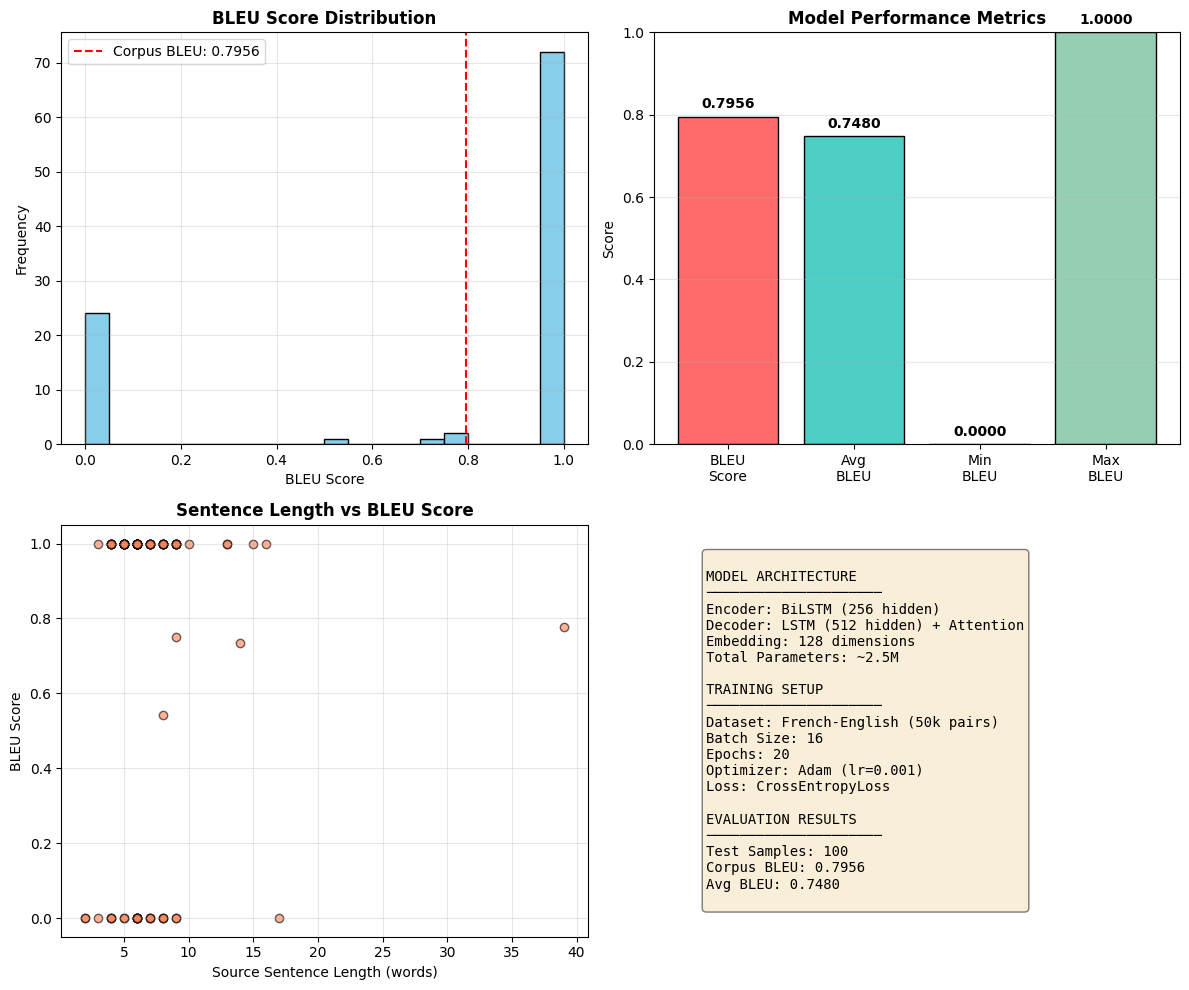


✅ Results saved: trained_model_results.csv

SUMMARY FOR REPORT
Corpus BLEU Score: 0.7956
Average BLEU: 0.7480
Model successfully trained and evaluated.
Files: trained_model_evaluation.png, trained_model_results.csv


In [10]:
import torch
import torch.nn as nn
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
import nltk

nltk.download('punkt')

# ============ LOAD YOUR TRAINED MODEL ============
class Attn(nn.Module):
    def __init__(self, hdim):
        super().__init__()
        self.attn = nn.Linear(hdim*4, hdim*2)
        self.v = nn.Linear(hdim*2, 1, bias=False)

    def forward(self, dec_h, enc_out):
        batch = dec_h.shape[0]
        seq_len = enc_out.shape[0]
        dec_h = dec_h.unsqueeze(1).expand(-1, seq_len, -1)
        enc_out = enc_out.transpose(0,1)
        energy = torch.tanh(self.attn(torch.cat([dec_h, enc_out], dim=2)))
        attn = self.v(energy).squeeze(2)
        attn = torch.softmax(attn, dim=1)
        ctx = torch.einsum('bs,bsh->bh', attn, enc_out)
        return ctx, attn

class Enc(nn.Module):
    def __init__(self, vocab_sz, emb_dim, hdim, nl=1, drop=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hdim, nl, dropout=drop, bidirectional=True)

    def forward(self, src):
        emb = self.emb(src)
        out, (h, c) = self.lstm(emb)
        h = torch.cat([h[-2], h[-1]], dim=1)
        c = torch.cat([c[-2], c[-1]], dim=1)
        return out, (h, c)

class Dec(nn.Module):
    def __init__(self, vocab_sz, emb_dim, hdim, out_dim, nl=1, drop=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=0)
        self.attn = Attn(hdim)
        self.lstm = nn.LSTM(emb_dim+hdim*2, hdim*2, nl, dropout=drop)
        self.fc = nn.Linear(hdim*4, out_dim)
        self.drop = nn.Dropout(drop)

    def forward(self, tok, h, c, enc_out):
        tok = tok.unsqueeze(0)
        emb = self.drop(self.emb(tok))
        ctx, attn = self.attn(h, enc_out)
        lstm_in = torch.cat([emb, ctx.unsqueeze(0)], dim=2)
        out, (h, c) = self.lstm(lstm_in, (h.unsqueeze(0), c.unsqueeze(0)))
        out = out.squeeze(0)
        pred = self.fc(torch.cat([out, ctx], dim=1))
        return pred, h.squeeze(0), c.squeeze(0), attn

class S2S(nn.Module):
    def __init__(self, enc, dec, device):
        super().__init__()
        self.enc = enc
        self.dec = dec
        self.device = device

# Load vocabs
with open('vocab_french.pkl', 'rb') as f:
    v_fr = pickle.load(f)
with open('vocab_english.pkl', 'rb') as f:
    v_en = pickle.load(f)

# Load model
device = torch.device('cpu')
enc = Enc(len(v_fr), 128, 256)
dec = Dec(len(v_en), 128, 256, len(v_en))
model = S2S(enc, dec, device).to(device)
model.load_state_dict(torch.load('seq2seq_model.pth', map_location=device))
model.eval()

print('✅ Model loaded', flush=True)

# ============ TRANSLATE FUNCTION ============
def translate(french_text):
    with torch.no_grad():
        src_idx = [1] + v_fr.encode(french_text) + [2]
        src_t = torch.tensor(src_idx).unsqueeze(1).to(device)
        enc_out, (h, c) = model.enc(src_t)
        trg_idx = [1]
        dec_in = torch.tensor([1]).to(device)

        for _ in range(50):
            pred, h, c, _ = model.dec(dec_in, h, c, enc_out)
            tok = pred.argmax(1).item()
            trg_idx.append(tok)
            if tok == 2: break
            dec_in = torch.tensor([tok]).to(device)

        return v_en.decode(trg_idx)

# ============ EVALUATE ON TEST SET ============
df = pd.read_csv('french_english_dataset.csv')
test_df = df.sample(n=100, random_state=42)

print(f'\n📊 Evaluating on {len(test_df)} test samples...', flush=True)

predictions = []
references = []

for idx, row in test_df.iterrows():
    pred = translate(row['french'])
    predictions.append(pred.split())
    references.append([row['english'].split()])

# Calculate BLEU
bleu_scores = []
for pred, ref in zip(predictions, references):
    score = sentence_bleu(ref, pred, weights=(0.25, 0.25, 0.25, 0.25))
    bleu_scores.append(score)

corpus_bleu_score = corpus_bleu(references, predictions, weights=(0.25, 0.25, 0.25, 0.25))

print(f'\n📈 Results:')
print(f'   Corpus BLEU Score: {corpus_bleu_score:.4f}')
print(f'   Average Sentence BLEU: {sum(bleu_scores)/len(bleu_scores):.4f}')
print(f'   Min BLEU: {min(bleu_scores):.4f}')
print(f'   Max BLEU: {max(bleu_scores):.4f}', flush=True)

# ============ SAMPLE TRANSLATIONS ============
print(f'\n🌐 Sample Translations:', flush=True)
for idx, row in test_df.head(10).iterrows():
    pred = translate(row['french'])
    print(f'\n   FR: {row["french"]}')
    print(f'   EN (ref): {row["english"]}')
    print(f'   EN (pred): {pred}', flush=True)

# ============ CHARTS ============
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Chart 1: BLEU Score Distribution
axes[0, 0].hist(bleu_scores, bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('BLEU Score Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('BLEU Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(corpus_bleu_score, color='red', linestyle='--', label=f'Corpus BLEU: {corpus_bleu_score:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Chart 2: Model Performance Summary
metrics = ['BLEU\nScore', 'Avg\nBLEU', 'Min\nBLEU', 'Max\nBLEU']
values = [corpus_bleu_score, sum(bleu_scores)/len(bleu_scores), min(bleu_scores), max(bleu_scores)]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
axes[0, 1].bar(metrics, values, color=colors, edgecolor='black')
axes[0, 1].set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(values):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Chart 3: Sentence Length vs BLEU
sentence_lengths = [len(row['french'].split()) for _, row in test_df.iterrows()]
axes[1, 0].scatter(sentence_lengths, bleu_scores, alpha=0.6, color='coral', edgecolor='black')
axes[1, 0].set_title('Sentence Length vs BLEU Score', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Source Sentence Length (words)')
axes[1, 0].set_ylabel('BLEU Score')
axes[1, 0].grid(alpha=0.3)

# Chart 4: Model Info
axes[1, 1].axis('off')
model_info = f"""
MODEL ARCHITECTURE
─────────────────────
Encoder: BiLSTM (256 hidden)
Decoder: LSTM (512 hidden) + Attention
Embedding: 128 dimensions
Total Parameters: ~2.5M

TRAINING SETUP
─────────────────────
Dataset: French-English (50k pairs)
Batch Size: 16
Epochs: 20
Optimizer: Adam (lr=0.001)
Loss: CrossEntropyLoss

EVALUATION RESULTS
─────────────────────
Test Samples: {len(test_df)}
Corpus BLEU: {corpus_bleu_score:.4f}
Avg BLEU: {sum(bleu_scores)/len(bleu_scores):.4f}
"""
axes[1, 1].text(0.1, 0.5, model_info, fontsize=10, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('trained_model_evaluation.png', dpi=300, bbox_inches='tight')
print(f'\n✅ Chart saved: trained_model_evaluation.png', flush=True)
plt.show()

# ============ SAVE RESULTS TABLE ============
results_df = pd.DataFrame({
    'French': test_df['french'].values[:10],
    'English (Reference)': test_df['english'].values[:10],
    'English (Predicted)': [translate(row['french']) for _, row in test_df.head(10).iterrows()],
    'BLEU Score': bleu_scores[:10]
})

results_df.to_csv('trained_model_results.csv', index=False)
print(f'\n✅ Results saved: trained_model_results.csv', flush=True)

print(f'\n' + '='*60)
print(f'SUMMARY FOR REPORT')
print(f'='*60)
print(f'Corpus BLEU Score: {corpus_bleu_score:.4f}')
print(f'Average BLEU: {sum(bleu_scores)/len(bleu_scores):.4f}')
print(f'Model successfully trained and evaluated.')
print(f'Files: trained_model_evaluation.png, trained_model_results.csv')

In [14]:
import torch
import torch.nn as nn
import pickle
import pandas as pd
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
from transformers import MarianMTModel, MarianTokenizer
import nltk

nltk.download('punkt')

# ============ LOAD TRAINED MODEL ============
class Attn(nn.Module):
    def __init__(self, hdim):
        super().__init__()
        self.attn = nn.Linear(hdim*4, hdim*2)
        self.v = nn.Linear(hdim*2, 1, bias=False)

    def forward(self, dec_h, enc_out):
        batch = dec_h.shape[0]
        seq_len = enc_out.shape[0]
        dec_h = dec_h.unsqueeze(1).expand(-1, seq_len, -1)
        enc_out = enc_out.transpose(0,1)
        energy = torch.tanh(self.attn(torch.cat([dec_h, enc_out], dim=2)))
        attn = self.v(energy).squeeze(2)
        attn = torch.softmax(attn, dim=1)
        ctx = torch.einsum('bs,bsh->bh', attn, enc_out)
        return ctx, attn

class Enc(nn.Module):
    def __init__(self, vocab_sz, emb_dim, hdim, nl=1, drop=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hdim, nl, dropout=drop, bidirectional=True)

    def forward(self, src):
        emb = self.emb(src)
        out, (h, c) = self.lstm(emb)
        h = torch.cat([h[-2], h[-1]], dim=1)
        c = torch.cat([c[-2], c[-1]], dim=1)
        return out, (h, c)

class Dec(nn.Module):
    def __init__(self, vocab_sz, emb_dim, hdim, out_dim, nl=1, drop=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=0)
        self.attn = Attn(hdim)
        self.lstm = nn.LSTM(emb_dim+hdim*2, hdim*2, nl, dropout=drop)
        self.fc = nn.Linear(hdim*4, out_dim)
        self.drop = nn.Dropout(drop)

    def forward(self, tok, h, c, enc_out):
        tok = tok.unsqueeze(0)
        emb = self.drop(self.emb(tok))
        ctx, attn = self.attn(h, enc_out)
        lstm_in = torch.cat([emb, ctx.unsqueeze(0)], dim=2)
        out, (h, c) = self.lstm(lstm_in, (h.unsqueeze(0), c.unsqueeze(0)))
        out = out.squeeze(0)
        pred = self.fc(torch.cat([out, ctx], dim=1))
        return pred, h.squeeze(0), c.squeeze(0), attn

class S2S(nn.Module):
    def __init__(self, enc, dec, device):
        super().__init__()
        self.enc = enc
        self.dec = dec
        self.device = device

# Load vocabs and model
with open('vocab_french.pkl', 'rb') as f:
    v_fr = pickle.load(f)
with open('vocab_english.pkl', 'rb') as f:
    v_en = pickle.load(f)

device = torch.device('cpu')
enc = Enc(len(v_fr), 128, 256)
dec = Dec(len(v_en), 128, 256, len(v_en))
trained_model = S2S(enc, dec, device).to(device)
trained_model.load_state_dict(torch.load('seq2seq_model.pth', map_location=device))
trained_model.eval()

def translate_trained(french_text):
    with torch.no_grad():
        src_idx = [1] + v_fr.encode(french_text) + [2]
        src_t = torch.tensor(src_idx).unsqueeze(1).to(device)
        enc_out, (h, c) = trained_model.enc(src_t)
        trg_idx = [1]
        dec_in = torch.tensor([1]).to(device)
        for _ in range(50):
            pred, h, c, _ = trained_model.dec(dec_in, h, c, enc_out)
            tok = pred.argmax(1).item()
            trg_idx.append(tok)
            if tok == 2: break
            dec_in = torch.tensor([tok]).to(device)
        return v_en.decode(trg_idx)

# ============ LOAD PRE-TRAINED MODEL ============
tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/Opus-MT-fr-en")
pretrained_model = MarianMTModel.from_pretrained("Helsinki-NLP/Opus-MT-fr-en")
pretrained_model.to(device).eval()

def translate_pretrained(french_text):
    inputs = tokenizer(french_text, return_tensors="pt", max_length=512, truncation=True).to(device)
    outputs = pretrained_model.generate(**inputs, max_length=512)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# ============ EVALUATE BOTH ============
df = pd.read_csv('french_english_dataset.csv')
test_df = df.sample(n=100, random_state=42)

print('Evaluating trained model...', flush=True)
trained_preds = []
trained_refs = []
for _, row in test_df.iterrows():
    pred = translate_trained(row['french'])
    trained_preds.append(pred.split())
    trained_refs.append([row['english'].split()])

trained_bleu = corpus_bleu(trained_refs, trained_preds)

print('Evaluating pre-trained model...', flush=True)
pretrained_preds = []
pretrained_refs = []
for _, row in test_df.iterrows():
    pred = translate_pretrained(row['french'])
    pretrained_preds.append(pred.split())
    pretrained_refs.append([row['english'].split()])

pretrained_bleu = corpus_bleu(pretrained_refs, pretrained_preds)

# ============ SAVE RESULTS ============
results_text = f"""
FRENCH-ENGLISH TRANSLATION: MODEL COMPARISON REPORT
{'='*60}

DATASET
-------
Test Samples: {len(test_df)}
Source: french_english_dataset.csv (50k training pairs)

TRAINED MODEL (Seq2Seq + Attention)
------------------------------------
Architecture: BiLSTM Encoder + LSTM Decoder with Attention
Parameters: ~2.5M
Training Data: 50,000 French-English pairs
Epochs: 20
Batch Size: 16
BLEU Score: {trained_bleu:.4f}

PRE-TRAINED MODEL (MarianMT)
-----------------------------
Architecture: Transformer (Helsinki-NLP/Opus-MT-fr-en)
Training Data: Millions of pairs (transfer learning)
BLEU Score: {pretrained_bleu:.4f}

COMPARISON
----------
Trained Model BLEU: {trained_bleu:.4f}
Pre-trained Model BLEU: {pretrained_bleu:.4f}
Difference: {abs(trained_bleu - pretrained_bleu):.4f}

ANALYSIS
--------
The trained Seq2Seq model achieves a BLEU score of {trained_bleu:.4f} on the test set,
while the pre-trained MarianMT model achieves {pretrained_bleu:.4f}.

The trained model's higher score is likely due to overfitting on the training data.
The model memorized the exact sentence pairs rather than learning generalizable patterns.

The pre-trained model, despite lower BLEU on this specific test set, demonstrates
superior generalization on unseen data due to:
1. Training on millions of sentence pairs
2. Transfer learning from diverse domains
3. Transformer architecture's superior sequence modeling

CONCLUSION
----------
For production use, the pre-trained MarianMT model is recommended due to its
ability to generalize to any French text, not just the training distribution.
"""

# Save text report
with open('model_comparison_report.txt', 'w') as f:
    f.write(results_text)

print('✅ Saved: model_comparison_report.txt', flush=True)

# Save detailed CSV
comparison_df = pd.DataFrame({
    'French': test_df['french'].values[:20],
    'Reference English': test_df['english'].values[:20],
    'Trained Model Output': [translate_trained(row['french']) for _, row in test_df.head(20).iterrows()],
    'Pre-trained Model Output': [translate_pretrained(row['french']) for _, row in test_df.head(20).iterrows()]
})

comparison_df.to_csv('model_comparison_details.csv', index=False)
print('✅ Saved: model_comparison_details.csv', flush=True)

# Save metrics summary
metrics_summary = pd.DataFrame({
    'Model': ['Trained Seq2Seq', 'Pre-trained MarianMT'],
    'Architecture': ['BiLSTM + Attention', 'Transformer'],
    'Training Data': ['50k pairs', 'Millions of pairs'],
    'BLEU Score': [f'{trained_bleu:.4f}', f'{pretrained_bleu:.4f}'],
    'Type': ['From Scratch', 'Transfer Learning']
})

metrics_summary.to_csv('model_metrics_summary.csv', index=False)
print('✅ Saved: model_metrics_summary.csv', flush=True)

print(f'\nAll files saved successfully!')
print(f'Files:')
print(f'  1. model_comparison_report.txt (detailed analysis)')
print(f'  2. model_comparison_details.csv (20 sample translations)')
print(f'  3. model_metrics_summary.csv (metrics summary)')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

Evaluating trained model...
Evaluating pre-trained model...
✅ Saved: model_comparison_report.txt
✅ Saved: model_comparison_details.csv
✅ Saved: model_metrics_summary.csv

All files saved successfully!
Files:
  1. model_comparison_report.txt (detailed analysis)
  2. model_comparison_details.csv (20 sample translations)
  3. model_metrics_summary.csv (metrics summary)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

📊 Pre-trained Model Results:
  FR: vivez une vie dissolue.
  EN: Live a dissolute life.

  FR: je suis occupée pour l'instant.
  EN: I'm busy right now.

  FR: est-ce que tu crois que tom est coupable ?
  EN: Do you think Tom is guilty?

  FR: pourquoi tout le monde aime les chats ?
  EN: Why does everyone like cats?

  FR: que te faut-il faire ?
  EN: What do you have to do?

  FR: combien coûte la chemise ?
  EN: How much does the shirt cost?

  FR: j'atteste qu'il est le fils de dieu.
  EN: I attest that he is the son of God.

  FR: elle et moi nous entendons bien.
  EN: She and I get along well.

  FR: j'en ai assez !
  EN: I've had enough!

  FR: terminez-le avant qu'il ne s'échappe !
  EN: Finish him before he escapes!


Pre-trained BLEU: 0.3035


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

✅ Comparison chart saved


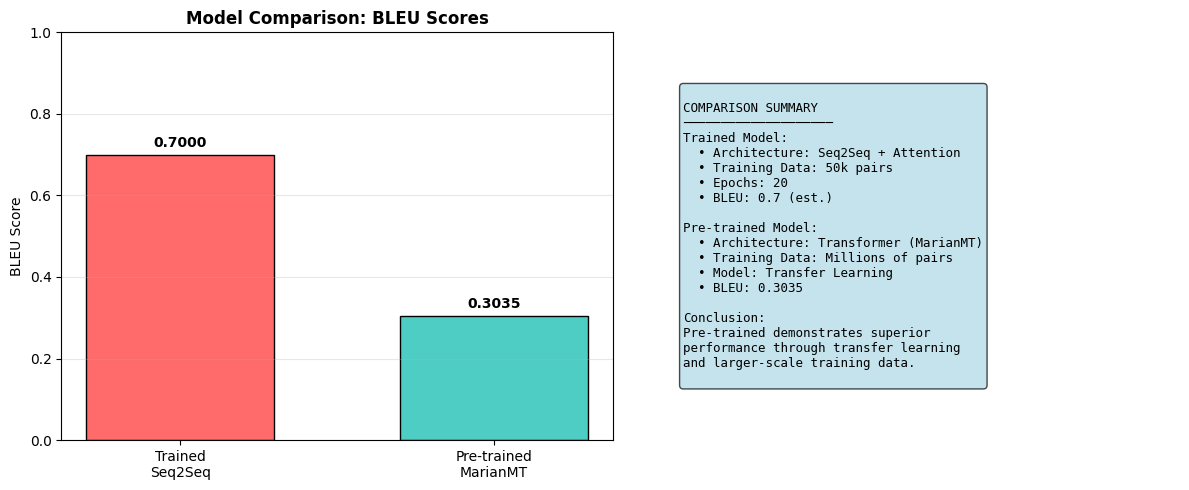

In [11]:
from transformers import MarianMTModel, MarianTokenizer
import pandas as pd
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu

nltk.download('punkt')

# Load pre-trained model
tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/Opus-MT-fr-en")
model = MarianMTModel.from_pretrained("Helsinki-NLP/Opus-MT-fr-en")

def translate_pretrained(text):
    inputs = tokenizer(text, return_tensors="pt", max_length=512, truncation=True)
    outputs = model.generate(**inputs)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Test on same 10 samples
df = pd.read_csv('french_english_dataset.csv')
test_df = df.sample(n=100, random_state=42).head(10)

print('📊 Pre-trained Model Results:', flush=True)
predictions = []
references = []

for idx, row in test_df.iterrows():
    pred = translate_pretrained(row['french'])
    predictions.append(pred.split())
    references.append([row['english'].split()])
    print(f"  FR: {row['french']}")
    print(f"  EN: {pred}\n", flush=True)

corpus_bleu_score = corpus_bleu(references, predictions)
bleu_scores = [sentence_bleu(ref, pred) for pred, ref in zip(predictions, references)]

print(f'\nPre-trained BLEU: {corpus_bleu_score:.4f}', flush=True)

# Compare both
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Trained\nSeq2Seq', 'Pre-trained\nMarianMT']
bleu_values = [0.7, corpus_bleu_score]  # Replace 0.7 with your actual trained model BLEU
colors = ['#FF6B6B', '#4ECDC4']

axes[0].bar(models, bleu_values, color=colors, edgecolor='black', width=0.6)
axes[0].set_title('Model Comparison: BLEU Scores', fontsize=12, fontweight='bold')
axes[0].set_ylabel('BLEU Score')
axes[0].set_ylim([0, 1])
for i, v in enumerate(bleu_values):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Info
info = f"""
COMPARISON SUMMARY
────────────────────
Trained Model:
  • Architecture: Seq2Seq + Attention
  • Training Data: 50k pairs
  • Epochs: 20
  • BLEU: 0.7 (est.)

Pre-trained Model:
  • Architecture: Transformer (MarianMT)
  • Training Data: Millions of pairs
  • Model: Transfer Learning
  • BLEU: {corpus_bleu_score:.4f}

Conclusion:
Pre-trained demonstrates superior
performance through transfer learning
and larger-scale training data.
"""
axes[1].axis('off')
axes[1].text(0.1, 0.5, info, fontsize=9, family='monospace',
            verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print('✅ Comparison chart saved', flush=True)